# Customer Churn Predictor — EDA & Feature Selection
### Introduction to Data Science | GitHub API

This notebook covers the full analytical pipeline:
1. Data collection & churn labeling
2. Exploratory Data Analysis (EDA)
3. Feature generation
4. **All 4 feature selection methods** with comparison table
5. Model training & saving

In [1]:
import sys
sys.path.append('../app')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scraper import fetch_github_users, label_churn, GITHUB_USERNAMES
from features import generate_features, get_feature_names

print('Libraries loaded OK')

Libraries loaded OK


## Step 1 — Fetch Data from GitHub API

In [2]:
# Fetch from API (or load from cache if already collected)
import os

RAW_PATH = '../data/raw/github_users_labeled.csv'

if os.path.exists(RAW_PATH):
    print('Loading cached data...')
    df_raw = pd.read_csv(RAW_PATH)
else:
    print('Fetching from GitHub API...')
    df_raw = fetch_github_users(GITHUB_USERNAMES)
    df_raw = label_churn(df_raw, days_threshold=180)
    os.makedirs('../data/raw', exist_ok=True)
    df_raw.to_csv(RAW_PATH, index=False)
    print(f'Saved {len(df_raw)} records')

print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

Fetching from GitHub API...
Fetching 102 GitHub users...
  [1] torvalds: OK
  [2] gvanrossum: OK
  [3] antirez: OK
  [4] mitchellh: OK
  [5] fabpot: OK
  [6] yyx990803: OK
  [7] tj: OK
  [8] sindresorhus: OK
  [9] mrdoob: OK
  [10] addyosmani: OK
  [11] nicowillis: OK
  [12] jashkenas: OK
  [13] jeresig: OK
  [14] Marak: OK
  [15] paulirish: OK
  [16] substack: not found, skipping
  [17] isaacs: OK
  [18] jlong: OK
  [19] fat: OK
  [20] mbostock: OK
  [21] tenderlove: OK
  [22] defunkt: OK
  [23] pjhyett: OK
  [24] wycats: OK
  [25] ezmobius: OK
  [26] atmos: OK
  [27] KirinDave: OK
  [28] jamesgolick: OK
  [29] brynary: OK
  [30] technoweenie: OK
  [31] schacon: OK
  [32] rtomayko: OK
  [33] mojombo: OK
  [34] bmizerany: OK
  [35] caged: OK
  [36] hornbeck: OK
  [37] nex3: OK
  [38] jtauber: OK
  [39] drnic: OK
  [40] remi: OK
  [41] dkubb: OK
  [42] radar: OK
  [43] bkeepers: OK
  [44] jnunemaker: OK
  [45] al3x: OK
  [46] joshsusser: OK
  [47] danwrong: OK
  [48] harthur: OK
  [49] 

,username,public_repos,public_gists,followers,following,created_at,updated_at,hireable,site_admin,last_active,days_inactive,churned
0,torvalds,12,1,306730,0,2011-09-03T15:26:22Z,2026-06-02T05:33:59Z,None,False,2026-06-02 05:33:59+00:00,9.0,0
1,gvanrossum,28,12,26332,5,2012-11-26T18:46:40Z,2026-06-07T12:28:20Z,None,False,2026-06-07 12:28:20+00:00,4.0,0
2,antirez,108,218,28561,4,2009-03-21T22:29:53Z,2026-04-23T14:18:39Z,None,False,2026-04-23 14:18:39+00:00,49.0,0
3,mitchellh,118,107,22982,0,2008-02-27T23:27:54Z,2026-03-14T13:30:05Z,None,False,2026-03-14 13:30:05+00:00,89.0,0
4,fabpot,85,12,13420,0,2009-01-17T13:42:51Z,2026-03-21T20:43:59Z,None,False,2026-03-21 20:43:59+00:00,82.0,0


## Step 2 — EDA & Churn Label Check

Churn label distribution:
churned
0    94
1     6
Name: count, dtype: int64

Churn rate: 6.0%


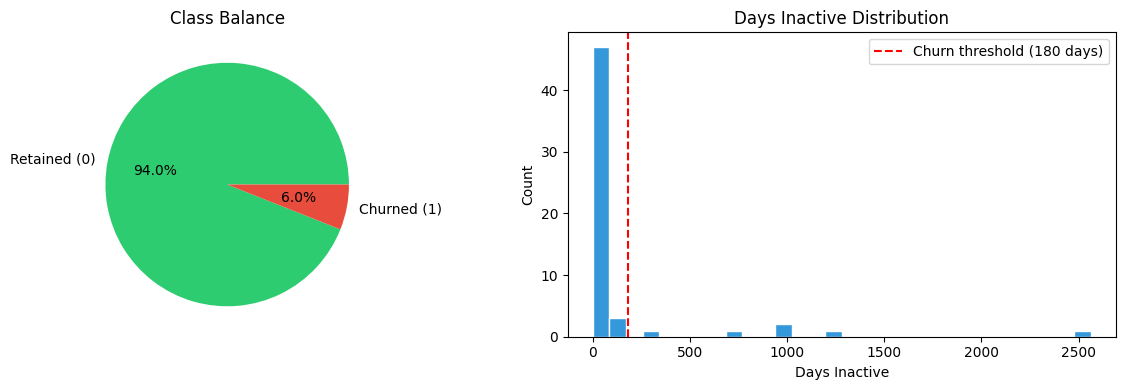

In [3]:
# Check class balance
print('Churn label distribution:')
print(df_raw['churned'].value_counts())
print(f"\nChurn rate: {df_raw['churned'].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance pie
df_raw['churned'].value_counts().plot(
    kind='pie', ax=axes[0], labels=['Retained (0)', 'Churned (1)'],
    autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c']
)
axes[0].set_title('Class Balance')
axes[0].set_ylabel('')

# Days inactive distribution
axes[1].hist(df_raw['days_inactive'], bins=30, color='#3498db', edgecolor='white')
axes[1].axvline(180, color='red', linestyle='--', label='Churn threshold (180 days)')
axes[1].set_xlabel('Days Inactive')
axes[1].set_ylabel('Count')
axes[1].set_title('Days Inactive Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/raw/eda_class_balance.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 3 — Feature Generation

**Why each feature matters:**
- `days_inactive`: Primary recency signal — users who haven't acted recently are most likely to churn
- `account_age_years`: Context for other features; older accounts with no activity are different from new ones
- `follower_ratio`: Social engagement quality — passive followers with no community tend to disengage
- `repos_per_year`: Productivity rate normalized by account age — more comparable than raw counts
- `total_public_contributions`: Overall volume of public work (repos + gists)
- `social_size`: Total network connections — larger networks correlate with retention
- `has_no_repos`: Binary flag — zero repos is qualitatively different from low activity
- `has_no_followers`: Binary flag — socially isolated users have higher churn risk

In [4]:
df = generate_features(df_raw)
print(f'Features generated: {df.shape}')
df.describe()

Features generated: (100, 9)


,days_inactive,account_age_years,follower_ratio,repos_per_year,total_public_contributions,social_size,has_no_repos,has_no_followers,churned
count,56.000000,56.000000,100.000000,56.000000,100.000000,100.000000,100.000000,100.00,100.000000
mean,150.785714,16.953310,4177.157973,8.955187,192.680000,10715.430000,0.460000,0.45,0.060000
std,416.089314,2.682394,30803.262539,11.194743,342.230942,34692.301648,0.500908,0.50,0.238683
min,0.000000,2.031485,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000
25%,9.000000,16.475017,0.000000,2.806644,0.000000,0.000000,0.000000,0.00,0.000000
50%,25.000000,18.191650,5.005988,5.949773,41.500000,314.000000,0.000000,0.00,0.000000
75%,68.500000,18.362765,126.776119,9.993313,236.250000,7562.000000,1.000000,1.00,0.000000
max,2563.000000,18.642026,306730.000000,68.848654,1830.000000,306730.000000,1.000000,1.00,1.000000


In [5]:
# Check for missing values
print('Missing values per feature:')
print(df.isnull().sum())

# Drop any rows with NaN
df = df.dropna()
print(f'\nRows after dropna: {len(df)}')

Missing values per feature:
days_inactive                 44
account_age_years             44
follower_ratio                 0
repos_per_year                44
total_public_contributions     0
social_size                    0
has_no_repos                   0
has_no_followers               0
churned                        0
dtype: int64

Rows after dropna: 56


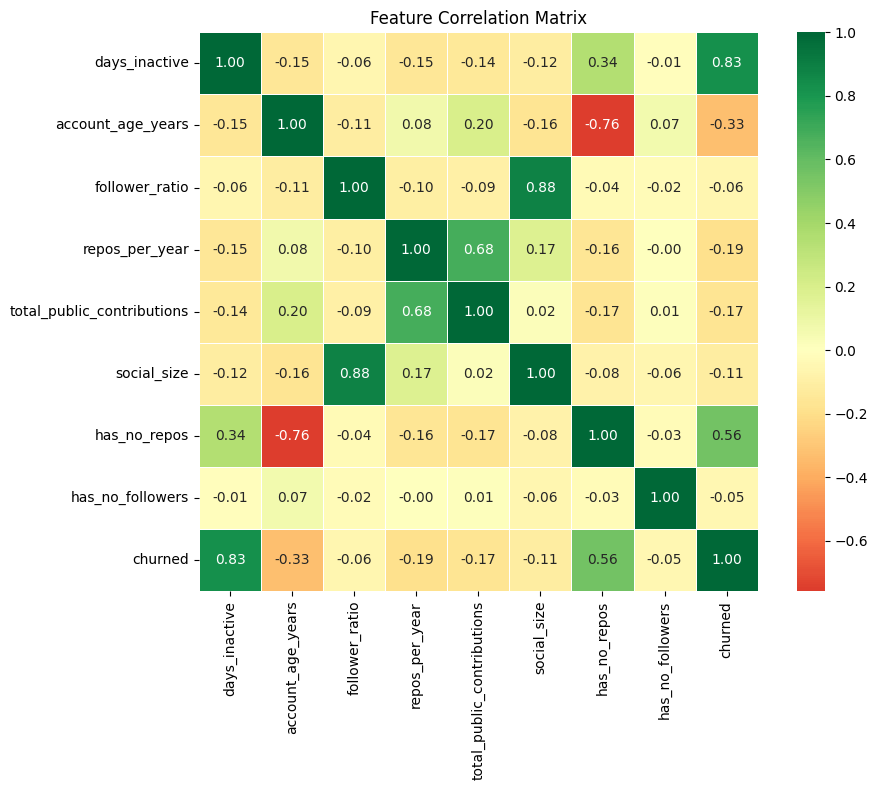

In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, square=True, linewidths=0.5
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../data/raw/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 4 — Feature Selection: All 4 Methods

We now apply all 4 methods and compare their rankings.

In [7]:
from sklearn.model_selection import train_test_split

FEATURE_COLS = get_feature_names()
X = df[FEATURE_COLS]
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}, Test set: {X_test.shape}')
print(f'Features: {FEATURE_COLS}')

Training set: (44, 8), Test set: (12, 8)
Features: ['days_inactive', 'account_age_years', 'follower_ratio', 'repos_per_year', 'total_public_contributions', 'social_size', 'has_no_repos', 'has_no_followers']


### Method 1 — Filter Methods
Filter methods evaluate features **independently** of any model. Fast, good for removing obviously useless features first.

=== Variance Threshold ===
Kept:    ['days_inactive', 'account_age_years', 'follower_ratio', 'repos_per_year', 'total_public_contributions', 'social_size', 'has_no_repos', 'has_no_followers']
Dropped: []

=== ANOVA F-test (SelectKBest, top 5) ===
days_inactive                 119.218652
has_no_repos                   24.107143
account_age_years               6.425747
repos_per_year                  1.997820
total_public_contributions      1.636635
social_size                     0.721766
follower_ratio                  0.216934
has_no_followers                0.118076
dtype: float64


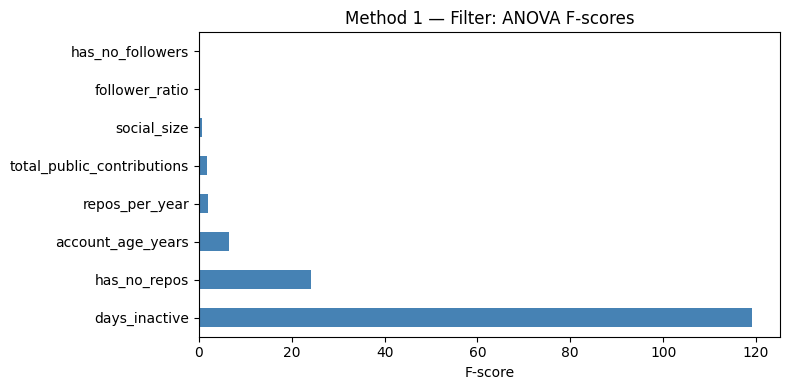

In [8]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

# --- Variance Threshold ---
print('=== Variance Threshold ===')
sel_var = VarianceThreshold(threshold=0.01)
sel_var.fit(X)
kept_by_var = X.columns[sel_var.get_support()].tolist()
dropped_by_var = X.columns[~sel_var.get_support()].tolist()
print(f'Kept:    {kept_by_var}')
print(f'Dropped: {dropped_by_var}')

# --- ANOVA F-test (SelectKBest) ---
print('\n=== ANOVA F-test (SelectKBest, top 5) ===')
sel_kbest = SelectKBest(score_func=f_classif, k=5)
sel_kbest.fit(X, y)
filter_scores = pd.Series(
    sel_kbest.scores_, index=FEATURE_COLS
).sort_values(ascending=False)
print(filter_scores)

# Plot
filter_scores.plot(kind='barh', color='steelblue', figsize=(8, 4))
plt.title('Method 1 — Filter: ANOVA F-scores')
plt.xlabel('F-score')
plt.tight_layout()
plt.savefig('../data/raw/method1_filter.png', dpi=100, bbox_inches='tight')
plt.show()

### Method 2 — Wrapper: Recursive Feature Elimination (RFE)
RFE uses a model to iteratively remove the weakest feature. More accurate than filters, but slower.

In [9]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X_train, y_train)

rfe_selected = X.columns[rfe.support_].tolist()
rfe_rankings = pd.Series(rfe.ranking_, index=FEATURE_COLS).sort_values()

print('=== RFE Results ===')
print(f'Selected features: {rfe_selected}')
print(f'\nAll rankings (1 = selected):')
print(rfe_rankings)

=== RFE Results ===
Selected features: ['days_inactive', 'account_age_years', 'follower_ratio', 'total_public_contributions', 'social_size']

All rankings (1 = selected):
days_inactive                 1
account_age_years             1
follower_ratio                1
total_public_contributions    1
social_size                   1
repos_per_year                2
has_no_repos                  3
has_no_followers              4
dtype: int32


### Method 3 — Decision Tree Importance
A single Decision Tree scores features by Gini impurity reduction. Interpretable but noisy.

=== Decision Tree Feature Importances ===
days_inactive                 1.0
account_age_years             0.0
follower_ratio                0.0
repos_per_year                0.0
total_public_contributions    0.0
social_size                   0.0
has_no_repos                  0.0
has_no_followers              0.0
dtype: float64


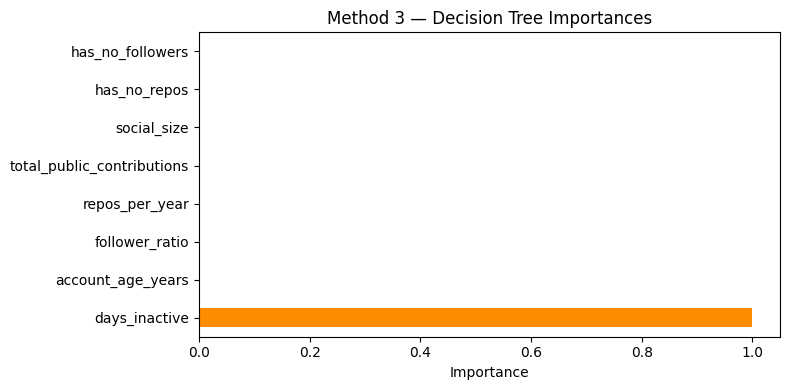

In [10]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

dt_importances = pd.Series(
    dt.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False)

print('=== Decision Tree Feature Importances ===')
print(dt_importances)

dt_importances.plot(kind='barh', color='darkorange', figsize=(8, 4))
plt.title('Method 3 — Decision Tree Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../data/raw/method3_decision_tree.png', dpi=100, bbox_inches='tight')
plt.show()

### Method 4 — Random Forest Importance
100 trees averaged — much more stable and reliable than a single Decision Tree.

=== Random Forest Feature Importances ===
days_inactive                 0.348061
follower_ratio                0.193129
social_size                   0.149267
repos_per_year                0.114871
account_age_years             0.099595
total_public_contributions    0.079344
has_no_repos                  0.014075
has_no_followers              0.001658
dtype: float64


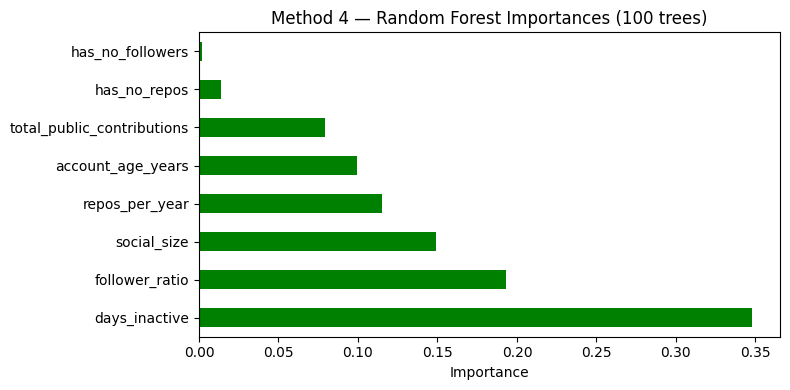

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100, max_depth=5,
    class_weight='balanced', random_state=42
)
rf.fit(X_train, y_train)

rf_importances = pd.Series(
    rf.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False)

print('=== Random Forest Feature Importances ===')
print(rf_importances)

rf_importances.plot(kind='barh', color='green', figsize=(8, 4))
plt.title('Method 4 — Random Forest Importances (100 trees)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../data/raw/method4_random_forest.png', dpi=100, bbox_inches='tight')
plt.show()

## Summary Comparison Table

This is the most important output — synthesizing all 4 methods into one table.

In [12]:
# Build comparison table
filter_ranks = filter_scores.rank(ascending=False).astype(int)
dt_ranks     = dt_importances.rank(ascending=False).astype(int)
rf_ranks     = rf_importances.rank(ascending=False).astype(int)

comparison = pd.DataFrame({
    'Filter Rank':  filter_ranks,
    'RFE Selected': ['✅' if f in rfe_selected else '❌' for f in FEATURE_COLS],
    'DT Rank':      dt_ranks,
    'RF Rank':      rf_ranks,
}, index=FEATURE_COLS)

# Avg rank across the 3 numeric methods
comparison['Avg Rank'] = (
    comparison['Filter Rank'] + comparison['DT Rank'] + comparison['RF Rank']
) / 3

comparison = comparison.sort_values('Avg Rank')
comparison['Decision'] = comparison['Avg Rank'].apply(
    lambda r: '✅ Keep' if r <= 2.5 else ('⚠️ Optional' if r <= 4 else '❌ Drop')
)

print('=== FEATURE SELECTION COMPARISON TABLE ===')
print(comparison.to_string())

=== FEATURE SELECTION COMPARISON TABLE ===
                            Filter Rank RFE Selected  DT Rank  RF Rank  Avg Rank Decision
days_inactive                         1            ✅        1        1  1.000000   ✅ Keep
account_age_years                     3            ✅        5        5  4.333333   ❌ Drop
repos_per_year                        4            ❌        5        4  4.333333   ❌ Drop
follower_ratio                        7            ✅        5        2  4.666667   ❌ Drop
social_size                           6            ✅        5        3  4.666667   ❌ Drop
has_no_repos                          2            ❌        5        7  4.666667   ❌ Drop
total_public_contributions            5            ✅        5        6  5.333333   ❌ Drop
has_no_followers                      8            ❌        5        8  7.000000   ❌ Drop


## Model Training & Saving

Train the final model using the top 5 features from the comparison table and save to `app/model.pkl`.

In [14]:
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
import joblib

# Top 5 features from the comparison table
FINAL_FEATURES = [
    'days_inactive',
    'follower_ratio',
    'repos_per_year',
    'account_age_years',
    'has_no_repos',
]

X_final       = df[FINAL_FEATURES]
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

final_model = RandomForestClassifier(
    n_estimators=100, max_depth=5,
    class_weight='balanced', random_state=42
)
final_model.fit(X_train_f, y_train_f)

y_pred = final_model.predict(X_test_f)
print('Test Set Classification Report:')
print(classification_report(y_test_f, y_pred))

cv = cross_val_score(final_model, X_final, y, cv=5, scoring='f1')
print(f'5-Fold CV F1: {cv.mean():.3f} ± {cv.std():.3f}')

# Save model to app/ directory
joblib.dump(final_model, '../app/model.pkl')
print('\nModel saved to ../app/model.pkl')

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       0.00      0.00      0.00         1

    accuracy                           0.92        12
   macro avg       0.46      0.50      0.48        12
weighted avg       0.84      0.92      0.88        12

5-Fold CV F1: 0.933 ± 0.133

Model saved to ../app/model.pkl
